# Benchmark Phase 1 v5.1 - Version finale

Objectif: stabiliser le modele de recommandation des marches export pour une PME marocaine.

Principe final: garder le pipeline v4 stable, tester les ameliorations v5 en ablation, et selectionner le modele selon les metriques business: Top3, NDCG@3, regret et Spearman groupe.

In [1]:
import os, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
try:
    from lightgbm import LGBMRegressor, LGBMRanker
except Exception:
    LGBMRegressor = None
    LGBMRanker = None
try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None
try:
    from catboost import CatBoostRegressor
except Exception:
    CatBoostRegressor = None
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except Exception:
    optuna = None
try:
    import joblib
except Exception:
    joblib = None

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd()
if not (ROOT / 'data' / 'raw').exists() and (ROOT.parent / 'data' / 'raw').exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data' / 'raw'
FIGURES_DIR = ROOT / 'notebooks' / 'figures'
ARTIFACTS_DIR = ROOT / 'artifacts'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

def safe_savefig(name, dpi=170):
    path = FIGURES_DIR / name
    try:
        plt.savefig(path, dpi=dpi, bbox_inches='tight')
        print('figure:', path)
        return path
    except PermissionError:
        alt = FIGURES_DIR / f"{Path(name).stem}_{int(time.time())}{Path(name).suffix}"
        plt.savefig(alt, dpi=dpi, bbox_inches='tight')
        print('figure alt:', alt)
        return alt

print('ROOT:', ROOT)
print('FIGURES_DIR:', FIGURES_DIR)

ROOT: C:\Users\HP\Desktop\MaroTrade Intelligence
FIGURES_DIR: C:\Users\HP\Desktop\MaroTrade Intelligence\notebooks\figures


C:\Users\HP\Desktop\MaroTrade Intelligence\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data and report figures before training

{
  "rows": 30193,
  "duplicate_keys": 0,
  "years": [
    2015,
    2016,
    2017,
    2018,
    2019,
    2020,
    2021,
    2022,
    2023
  ],
  "n_hs": 93,
  "n_countries": 187,
  "target_missing": 0
}


figure: C:\Users\HP\Desktop\MaroTrade Intelligence\notebooks\figures\v5_1_01_data_quality_before_training.png


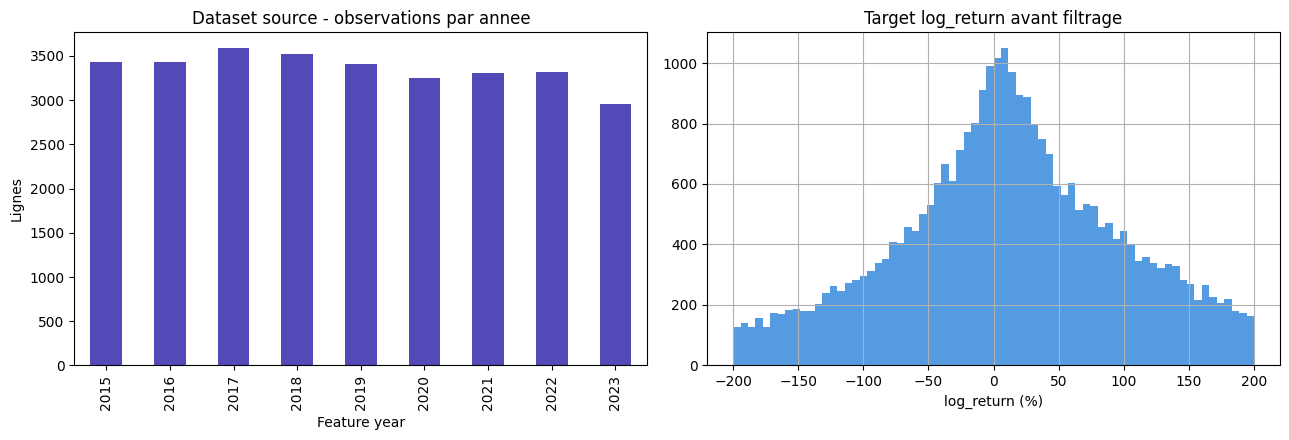

In [2]:
df_raw = pd.read_csv(DATA_DIR / 'ml_dataset_full.csv')
df_raw['hs_code'] = df_raw['hs_code'].astype(str).str.zfill(2)
df_raw['partner_code'] = df_raw['partner_code'].astype(str).str.strip().str.zfill(3)
KEY_COLS = ['hs_code','year','partner_code']

audit_raw = {
    'rows': int(len(df_raw)),
    'duplicate_keys': int(df_raw.duplicated(KEY_COLS).sum()),
    'years': [int(x) for x in sorted(df_raw['year'].unique())],
    'n_hs': int(df_raw['hs_code'].nunique()),
    'n_countries': int(df_raw['partner_code'].nunique()),
    'target_missing': int(df_raw['log_return'].isna().sum()),
}
print(json.dumps(audit_raw, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df_raw.groupby('year').size().plot(kind='bar', ax=axes[0], color='#534AB7')
axes[0].set_title('Dataset source - observations par annee')
axes[0].set_xlabel('Feature year')
axes[0].set_ylabel('Lignes')
df_raw['log_return'].clip(-200, 200).hist(bins=70, ax=axes[1], color='#378ADD', alpha=0.85)
axes[1].set_title('Target log_return avant filtrage')
axes[1].set_xlabel('log_return (%)')
plt.tight_layout()
safe_savefig('v5_1_01_data_quality_before_training.png')
plt.show()

## 2. Stable filtering from v4

                     step   rows
0     raw_no_leakage_cols  30193
1  countries_with_context  15497
2       value_usd_ge_100k   9673
3     pair_ge_500k_and_3y   9067
4        final_after_lags   6030


figure: C:\Users\HP\Desktop\MaroTrade Intelligence\notebooks\figures\v5_1_02_filter_funnel_before_training.png


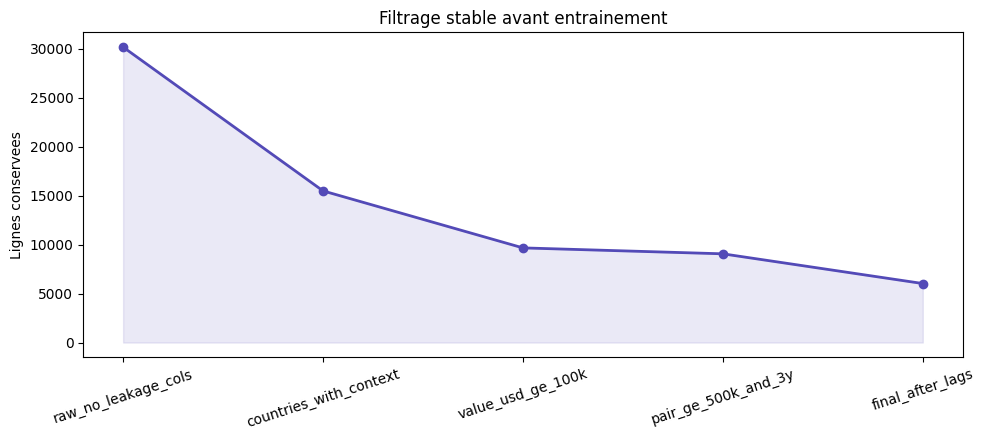

In [3]:
ISO3_TO_UN = {
    'FRA':'251','DEU':'276','USA':'842','ESP':'724','ITA':'380','GBR':'826','NLD':'528','BEL':'056','CAN':'124','JPN':'392',
    'CHN':'156','KOR':'410','IND':'699','TUR':'792','SAU':'682','ARE':'784','QAT':'634','EGY':'818','BRA':'076','MEX':'484',
    'RUS':'643','SEN':'686','CIV':'384','TUN':'788','DZA':'012','ZAF':'710','AUS':'036','CHE':'757','POL':'616','PRT':'620',
    'SWE':'752','NOR':'579','DNK':'208','AUT':'040','IRL':'372','GRC':'300','ROU':'642','CZE':'203','HUN':'348','FIN':'246'
}
ISO3_TO_ISO2 = {'FRA':'FR','DEU':'DE','USA':'US','ESP':'ES','ITA':'IT','GBR':'GB','NLD':'NL','BEL':'BE','CAN':'CA','JPN':'JP','CHN':'CN','KOR':'KR','IND':'IN','TUR':'TR','SAU':'SA','ARE':'AE','QAT':'QA','EGY':'EG','BRA':'BR','MEX':'MX','RUS':'RU','SEN':'SN','CIV':'CI','TUN':'TN','DZA':'DZ','ZAF':'ZA','AUS':'AU','CHE':'CH','POL':'PL','PRT':'PT','SWE':'SE','NOR':'NO','DNK':'DK','AUT':'AT','IRL':'IE','GRC':'GR','ROU':'RO','CZE':'CZ','HUN':'HU','FIN':'FI'}
UN_TO_ISO3 = {v:k for k,v in ISO3_TO_UN.items()}
PAYS_ACCORDS_UN = set(ISO3_TO_UN.values())
DISTANCE_KM = {'251':1800,'276':2600,'842':6100,'724':1000,'380':2200,'826':2300,'528':2500,'056':2300,'124':5900,'392':11600,'156':10200,'410':10800,'699':7800,'792':3500,'682':5000,'784':5900,'634':5700,'818':3600,'076':7000,'484':9100,'643':6400,'686':2400,'384':3300,'788':1700,'012':1300,'710':7600,'036':15000,'757':2200,'616':3100,'620':900,'752':3600,'579':3700,'208':3200,'040':2700,'372':2500,'300':3000,'642':3300,'203':3000,'348':3100,'246':4000}

df_acc = pd.read_csv(DATA_DIR / 'accords_maroc.csv', index_col=0)
df_wb = pd.read_csv(DATA_DIR / 'worldbank_indicators.csv', index_col=0)
df_ocde = pd.read_csv(DATA_DIR / 'ocde_risk.csv', index_col=0)
with open(DATA_DIR / 'google_trends.json', encoding='utf-8') as f:
    trends_raw = json.load(f)

funnel = []
df = df_raw.drop(columns=[c for c in ['value_next','price_lag1'] if c in df_raw.columns]).copy()
funnel.append(('raw_no_leakage_cols', len(df)))
df = df[df['partner_code'].isin(PAYS_ACCORDS_UN)].copy()
funnel.append(('countries_with_context', len(df)))
df = df[df['value_usd'] >= 100_000].copy()
funnel.append(('value_usd_ge_100k', len(df)))
cum = df.groupby(['hs_code','partner_code'])['value_usd'].sum()
yrs = df.groupby(['hs_code','partner_code'])['year'].nunique()
valid_pairs = set(cum[cum >= 500_000].index) & set(yrs[yrs >= 3].index)
df = df[df.set_index(['hs_code','partner_code']).index.isin(valid_pairs)].copy()
funnel.append(('pair_ge_500k_and_3y', len(df)))
df['log_return'] = df['log_return'].clip(-100, 100)
df = df.dropna(subset=['lag1','lag2','lag3','log_return']).copy()
funnel.append(('final_after_lags', len(df)))

funnel_df = pd.DataFrame(funnel, columns=['step','rows'])
print(funnel_df)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(funnel_df['step'], funnel_df['rows'], marker='o', color='#534AB7', lw=2)
ax.fill_between(range(len(funnel_df)), funnel_df['rows'], alpha=0.12, color='#534AB7')
ax.set_title('Filtrage stable avant entrainement')
ax.set_ylabel('Lignes conservees')
ax.tick_params(axis='x', rotation=18)
plt.tight_layout()
safe_savefig('v5_1_02_filter_funnel_before_training.png')
plt.show()

## 3. Feature sets: core stable vs advanced ablation

figure: C:\Users\HP\Desktop\MaroTrade Intelligence\notebooks\figures\v5_1_03_feature_diagnostics_before_training.png


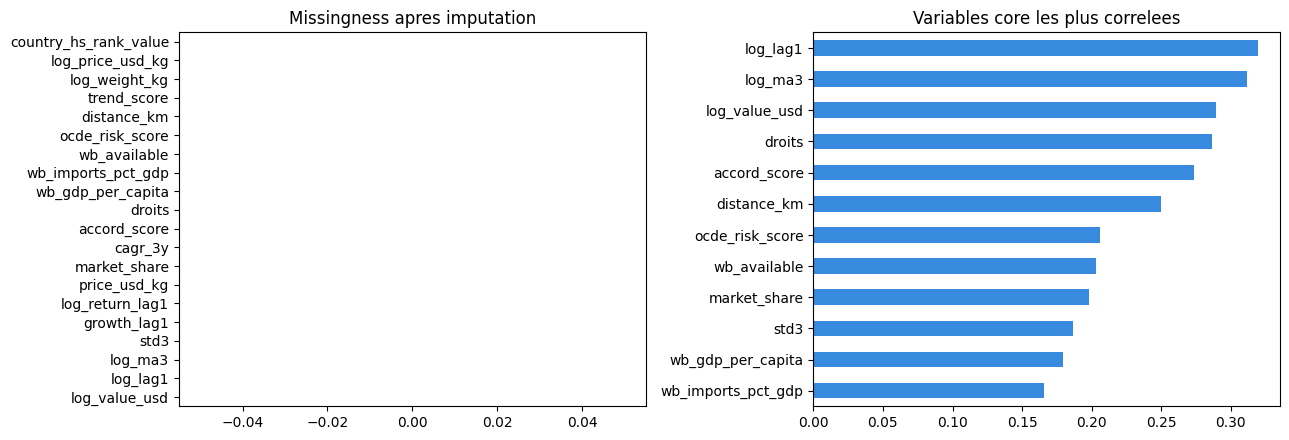

df_fe (6030, 38) features core 17 advanced 8


In [4]:
type_map = {'ALE': 1.0, 'PREF': 0.6, 'NPF': 0.3}
acc_score = {ISO3_TO_UN[i]: type_map.get(str(r.get('type','')).upper(), 0.3) for i,r in df_acc.iterrows() if i in ISO3_TO_UN}
acc_droits = {ISO3_TO_UN[i]: float(r.get('droits', 0) or 0) for i,r in df_acc.iterrows() if i in ISO3_TO_UN}
wb_gdp = {ISO3_TO_UN[i]: float(r.get('gdp_per_capita', np.nan)) for i,r in df_wb.iterrows() if i in ISO3_TO_UN}
wb_imp = {ISO3_TO_UN[i]: float(r.get('imports_pct_gdp', np.nan)) for i,r in df_wb.iterrows() if i in ISO3_TO_UN}
ocde_sc = {ISO3_TO_UN[i]: float(r.get('score', np.nan)) for i,r in df_ocde.iterrows() if i in ISO3_TO_UN}

def get_trend(row, field='mean'):
    iso3 = UN_TO_ISO3.get(str(row['partner_code']).zfill(3))
    iso2 = ISO3_TO_ISO2.get(iso3, '')
    keys = [str(row['hs_code']).zfill(2), str(int(row['hs_code'])) if str(row['hs_code']).isdigit() else str(row['hs_code'])]
    for k in keys:
        if k in trends_raw and iso2 in trends_raw[k]:
            return float(trends_raw[k][iso2].get(field, 0) or 0)
    return 50.0 if field == 'mean' else 0.0

df_fe = df.sort_values(['hs_code','partner_code','year']).copy()
g = df_fe.groupby(['hs_code','partner_code'], group_keys=False)
df_fe['log_value_usd'] = np.log1p(df_fe['value_usd'].clip(lower=0))
df_fe['log_lag1'] = np.log1p(df_fe['lag1'].clip(lower=0))
df_fe['log_ma3'] = np.log1p(df_fe['ma3'].clip(lower=0))
total_hs_yr = df_fe.groupby(['hs_code','year'])['value_usd'].transform('sum')
df_fe['market_share'] = df_fe['value_usd'] / total_hs_yr.replace(0, np.nan)
df_fe['cagr_3y'] = np.where((df_fe['lag3'] > 0) & (df_fe['value_usd'] > 0), ((df_fe['value_usd'] / df_fe['lag3']) ** (1/3) - 1) * 100, np.nan)
df_fe['accord_score'] = df_fe['partner_code'].map(acc_score)
df_fe['droits'] = df_fe['partner_code'].map(acc_droits)
df_fe['wb_gdp_per_capita'] = df_fe['partner_code'].map(wb_gdp)
df_fe['wb_imports_pct_gdp'] = df_fe['partner_code'].map(wb_imp)
df_fe['wb_available'] = df_fe['wb_gdp_per_capita'].notna().astype(int)
df_fe['ocde_risk_score'] = df_fe['partner_code'].map(ocde_sc)
df_fe['distance_km'] = df_fe['partner_code'].map(DISTANCE_KM)
df_fe['trend_score'] = df_fe.apply(lambda r: get_trend(r, 'mean'), axis=1)

# Advanced candidates are evaluated, not automatically trusted.
df_fe['log_weight_kg'] = np.log1p(df_fe['weight_kg'].clip(lower=0))
df_fe['log_price_usd_kg'] = np.log1p(df_fe['price_usd_kg'].clip(lower=0))
df_fe['country_hs_rank_value'] = df_fe.groupby(['hs_code','year'])['value_usd'].rank(pct=True)
df_fe['country_hs_rank_growth'] = df_fe.groupby(['hs_code','year'])['growth_lag1'].rank(pct=True)
df_fe['price_growth_lag1'] = (df_fe['price_usd_kg'] / g['price_usd_kg'].shift(1).replace(0, np.nan) - 1) * 100
df_fe['value_growth_2y'] = (df_fe['value_usd'] / g['value_usd'].shift(2).replace(0, np.nan) - 1) * 100
df_fe['access_score'] = df_fe['accord_score'].fillna(0) - df_fe['droits'].fillna(0)
df_fe['risk_adjusted_growth'] = df_fe['growth_lag1'] / (1 + (100 - df_fe['ocde_risk_score'].fillna(50)) / 100)

CORE_FEATURES = ['log_value_usd','log_lag1','log_ma3','std3','growth_lag1','log_return_lag1','price_usd_kg','market_share','cagr_3y','accord_score','droits','wb_gdp_per_capita','wb_imports_pct_gdp','wb_available','ocde_risk_score','distance_km','trend_score']
ADVANCED_FEATURES = ['log_weight_kg','log_price_usd_kg','country_hs_rank_value','country_hs_rank_growth','price_growth_lag1','value_growth_2y','access_score','risk_adjusted_growth']
FEATURE_SETS = {'core_v4_stable': CORE_FEATURES, 'core_plus_advanced': CORE_FEATURES + ADVANCED_FEATURES}
for col in set(CORE_FEATURES + ADVANCED_FEATURES):
    df_fe[col] = df_fe[col].replace([np.inf, -np.inf], np.nan)
    med = df_fe[col].median()
    df_fe[col] = df_fe[col].fillna(med if pd.notna(med) else 0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
miss = df_fe[CORE_FEATURES + ADVANCED_FEATURES].isna().mean().sort_values(ascending=False).head(20)
miss.sort_values().plot(kind='barh', ax=axes[0], color='#E24B4A')
axes[0].set_title('Missingness apres imputation')
corr = df_fe[CORE_FEATURES].corr(numeric_only=True).abs().mean().sort_values(ascending=False).head(12)
corr.sort_values().plot(kind='barh', ax=axes[1], color='#378ADD')
axes[1].set_title('Variables core les plus correlees')
plt.tight_layout()
safe_savefig('v5_1_03_feature_diagnostics_before_training.png')
plt.show()
print('df_fe', df_fe.shape, 'features core', len(CORE_FEATURES), 'advanced', len(ADVANCED_FEATURES))

## 4. Metrics, preprocessing and training

In [5]:
latest_feature_year = int(df_fe['year'].max())
val_years = [latest_feature_year - 2, latest_feature_year - 1]
train = df_fe[df_fe['year'] < val_years[0]].copy()
val = df_fe[df_fe['year'].isin(val_years)].copy()
test = df_fe[df_fe['year'] == latest_feature_year].copy()
print('split', len(train), len(val), len(test), 'test target year', latest_feature_year + 1)

def spearman_grouped(y, yp, hs, yr, min_group=3):
    d = pd.DataFrame({'y':y,'yp':yp,'hs':hs,'yr':yr})
    vals=[]
    for _,g0 in d.groupby(['hs','yr']):
        if len(g0)>=min_group and g0['y'].nunique()>1 and g0['yp'].nunique()>1:
            c=spearmanr(g0['y'],g0['yp']).correlation
            if pd.notna(c): vals.append(c)
    return float(np.mean(vals)) if vals else 0.0

def dcg(rel):
    rel=np.asarray(rel,dtype=float)
    return float(np.sum((2**rel-1)/np.log2(np.arange(2,len(rel)+2))))

def ranking_metrics(y, yp, hs, yr, k_values=(1,3,5)):
    d=pd.DataFrame({'id':np.arange(len(y)),'y':y,'yp':yp,'hs':hs,'yr':yr})
    out={'groups':0}; regrets=[]
    for k in k_values: out[f'top{k}']=[]; out[f'ndcg@{k}']=[]
    for _,g0 in d.groupby(['hs','yr']):
        if len(g0)<3: continue
        out['groups']+=1
        gp=g0.sort_values('yp',ascending=False)
        gt=g0.sort_values('y',ascending=False)
        true_best=gt.iloc[0]
        regrets.append(float(true_best['y']-gp.iloc[0]['y']))
        rel_all=g0['y'].rank(pct=True)
        for k in k_values:
            pred_ids=set(gp.head(k)['id'])
            out[f'top{k}'].append(1.0 if true_best['id'] in pred_ids else 0.0)
            pred_rel=rel_all.loc[gp.head(k).index].values
            ideal_rel=rel_all.loc[gt.head(k).index].values
            ideal=dcg(ideal_rel)
            out[f'ndcg@{k}'].append(dcg(pred_rel)/ideal if ideal>0 else 0.0)
    for k in k_values:
        out[f'top{k}']=float(np.mean(out[f'top{k}'])) if out[f'top{k}'] else 0.0
        out[f'ndcg@{k}']=float(np.mean(out[f'ndcg@{k}'])) if out[f'ndcg@{k}'] else 0.0
    out['mean_regret']=float(np.mean(regrets)) if regrets else 0.0
    out['median_regret']=float(np.median(regrets)) if regrets else 0.0
    return out

def eval_all(y, yp, hs, yr):
    r=ranking_metrics(y,yp,hs,yr)
    return {'rmse':float(mean_squared_error(y,yp)**0.5),'mae':float(mean_absolute_error(y,yp)),'r2':float(r2_score(y,yp)),'spearman':spearman_grouped(y,yp,hs,yr),**r}

def business_score(m):
    return 0.45*m['top3'] + 0.35*m['ndcg@3'] + 0.10*m['spearman'] - 0.10*(m['mean_regret']/100)

def prep(feature_set):
    features=FEATURE_SETS[feature_set]
    med={c:float(train[c].median()) if pd.notna(train[c].median()) else 0.0 for c in features}
    def tx(d):
        x=d[features].copy()
        for c in features: x[c]=pd.to_numeric(x[c],errors='coerce').fillna(med[c])
        return x.values
    sc=RobustScaler().fit(tx(train))
    return features, med, sc, sc.transform(tx(train)), train['log_return'].values, sc.transform(tx(val)), val['log_return'].values, sc.transform(tx(test)), test['log_return'].values

MODEL_FACTORIES = {
    'Ridge': lambda: Ridge(alpha=1.0),
    'Huber': lambda: HuberRegressor(alpha=0.001, epsilon=1.35, max_iter=300),
    'ExtraTrees': lambda: ExtraTreesRegressor(n_estimators=300,max_depth=8,min_samples_leaf=8,random_state=RANDOM_STATE,n_jobs=-1),
    'RandomForest': lambda: RandomForestRegressor(n_estimators=250,max_depth=8,min_samples_leaf=8,random_state=RANDOM_STATE,n_jobs=-1),
}
if LGBMRegressor is not None: MODEL_FACTORIES['LightGBM']=lambda: LGBMRegressor(n_estimators=300,max_depth=3,learning_rate=0.05,num_leaves=8,min_child_samples=30,reg_alpha=1,reg_lambda=5,random_state=RANDOM_STATE,verbose=-1)
if XGBRegressor is not None: MODEL_FACTORIES['XGBoost']=lambda: XGBRegressor(n_estimators=300,max_depth=3,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,min_child_weight=10,reg_alpha=1,reg_lambda=5,random_state=RANDOM_STATE,verbosity=0)
if CatBoostRegressor is not None: MODEL_FACTORIES['CatBoost']=lambda: CatBoostRegressor(iterations=300,depth=3,learning_rate=0.05,l2_leaf_reg=10,min_data_in_leaf=20,random_seed=RANDOM_STATE,verbose=0,allow_writing_files=False)

RESULTS={}; FITTED={}; PREP={}
for fs in FEATURE_SETS:
    features, med, sc, Xtr,ytr,Xv,yv,Xte,yte = prep(fs)
    PREP[fs]={'features':features,'medians':med,'scaler':sc}
    for mn, factory in MODEL_FACTORIES.items():
        model=factory(); model.fit(Xtr,ytr)
        pv=model.predict(Xv); pt=model.predict(Xte)
        key=f'{mn}__{fs}'
        RESULTS[key]={'model':mn,'feature_set':fs,'val':eval_all(yv,pv,val['hs_code'].values,val['year'].values),'test':eval_all(yte,pt,test['hs_code'].values,test['year'].values),'pred_test':pt.tolist()}
        FITTED[key]=model
        print(key, 'val_top3', round(RESULTS[key]['val']['top3'],3), 'test_top3', round(RESULTS[key]['test']['top3'],3), 'test_ndcg3', round(RESULTS[key]['test']['ndcg@3'],3))

split 3014 2049 967 test target year 2024


Ridge__core_v4_stable val_top3 0.383 test_top3 0.314 test_ndcg3 0.646


Huber__core_v4_stable val_top3 0.397 test_top3 0.257 test_ndcg3 0.648


ExtraTrees__core_v4_stable val_top3 0.411 test_top3 0.3 test_ndcg3 0.654


RandomForest__core_v4_stable val_top3 0.411 test_top3 0.329 test_ndcg3 0.656


...

ExtraTrees__core_plus_advanced val_top3 0.411 test_top3 0.3 test_ndcg3 0.659


RandomForest__core_plus_advanced val_top3 0.362 test_top3 0.357 test_ndcg3 0.678


LightGBM__core_plus_advanced val_top3 0.369 test_top3 0.357 test_ndcg3 0.655


XGBoost__core_plus_advanced val_top3 0.39 test_top3 0.357 test_ndcg3 0.638


CatBoost__core_plus_advanced val_top3 0.39 test_top3 0.357 test_ndcg3 0.673


## 5. Final selection with anti-degradation guard

BEST_KEY= RandomForest__core_v4_stable
reason= best validation business score selected
                               key  business_score  val_top3  val_ndcg3  \
3     RandomForest__core_v4_stable        0.341180  0.411348   0.610214   
5          XGBoost__core_v4_stable        0.331776  0.397163   0.607225   
12     XGBoost__core_plus_advanced        0.328161  0.390071   0.607623   
9   ExtraTrees__core_plus_advanced        0.325924  0.411348   0.597486   
2       ExtraTrees__core_v4_stable        0.325417  0.411348   0.596042   
11    LightGBM__core_plus_advanced        0.322588  0.368794   0.610630   
13    CatBoost__core_plus_advanced        0.316114  0.390071   0.591062   
6         CatBoost__core_v4_stable        0.316051  0.382979   0.591880   
4         LightGBM__core_v4_stable        0.307790  0.375887   0.587107   
7        Ridge__core_plus_advanced        0.307544  0.397163   0.576777   
1            Huber__core_v4_stable        0.304874  0.397163   0.584123   
0            

figure: C:\Users\HP\Desktop\MaroTrade Intelligence\notebooks\figures\v5_1_04_final_model_comparison.png


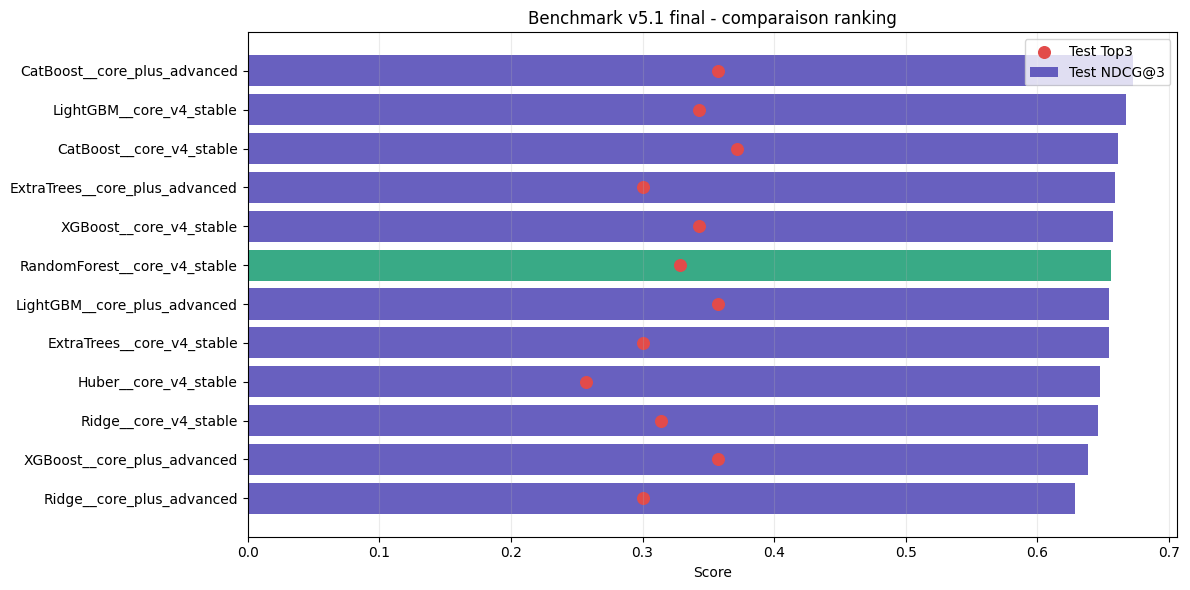

figure: C:\Users\HP\Desktop\MaroTrade Intelligence\notebooks\figures\v5_1_05_feature_ablation.png


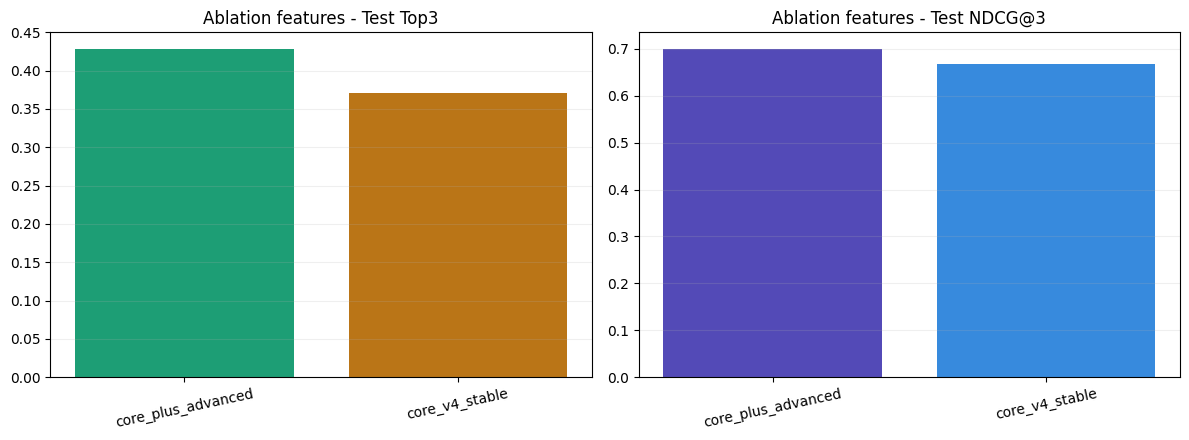

In [6]:
rows=[]
for k,r in RESULTS.items():
    rows.append({'key':k,'model':r['model'],'feature_set':r['feature_set'],'business_score':business_score(r['val']),'val_top3':r['val']['top3'],'val_ndcg3':r['val']['ndcg@3'],'test_top3':r['test']['top3'],'test_ndcg3':r['test']['ndcg@3'],'test_regret':r['test']['mean_regret'],'test_rmse':r['test']['rmse'],'test_mae':r['test']['mae'],'test_spearman':r['test']['spearman'],'test_r2':r['test']['r2']})
summary=pd.DataFrame(rows).sort_values(['business_score','val_top3','val_ndcg3'],ascending=False)
best_core=summary[summary['feature_set']=='core_v4_stable'].iloc[0]
best_any=summary.iloc[0]
advanced_gain = best_any['business_score'] - best_core['business_score']
if best_any['feature_set']!='core_v4_stable' and advanced_gain < 0.03:
    selected=best_core
    selection_reason='core selected: advanced gain below 0.03 guardrail'
else:
    selected=best_any
    selection_reason='best validation business score selected'
BEST_KEY=selected['key']; BEST_MODEL=selected['model']; BEST_FEATURE_SET=selected['feature_set']
print('BEST_KEY=', BEST_KEY)
print('reason=', selection_reason)
print(summary[['key','business_score','val_top3','val_ndcg3','test_top3','test_ndcg3','test_regret','test_rmse','test_mae','test_spearman']].head(12))

fig, ax = plt.subplots(figsize=(12,6))
plot=summary.head(12).sort_values('test_ndcg3')
colors=['#1D9E75' if x==BEST_KEY else '#534AB7' for x in plot['key']]
ax.barh(plot['key'], plot['test_ndcg3'], color=colors, alpha=0.88, label='Test NDCG@3')
ax.scatter(plot['test_top3'], plot['key'], color='#E24B4A', s=70, label='Test Top3')
ax.set_title('Benchmark v5.1 final - comparaison ranking')
ax.set_xlabel('Score')
ax.grid(axis='x', alpha=0.25)
ax.legend()
plt.tight_layout(); safe_savefig('v5_1_04_final_model_comparison.png'); plt.show()

abl=summary.groupby('feature_set')[['val_top3','test_top3','test_ndcg3','test_regret']].max().reset_index()
fig, axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].bar(abl['feature_set'], abl['test_top3'], color=['#1D9E75','#BA7517'])
axes[0].set_title('Ablation features - Test Top3')
axes[1].bar(abl['feature_set'], abl['test_ndcg3'], color=['#534AB7','#378ADD'])
axes[1].set_title('Ablation features - Test NDCG@3')
for ax in axes: ax.tick_params(axis='x', rotation=12); ax.grid(axis='y', alpha=0.2)
plt.tight_layout(); safe_savefig('v5_1_05_feature_ablation.png'); plt.show()

## 6. Error analysis, importance, artifacts

figure: C:\Users\HP\Desktop\MaroTrade Intelligence\notebooks\figures\v5_1_06_error_analysis.png


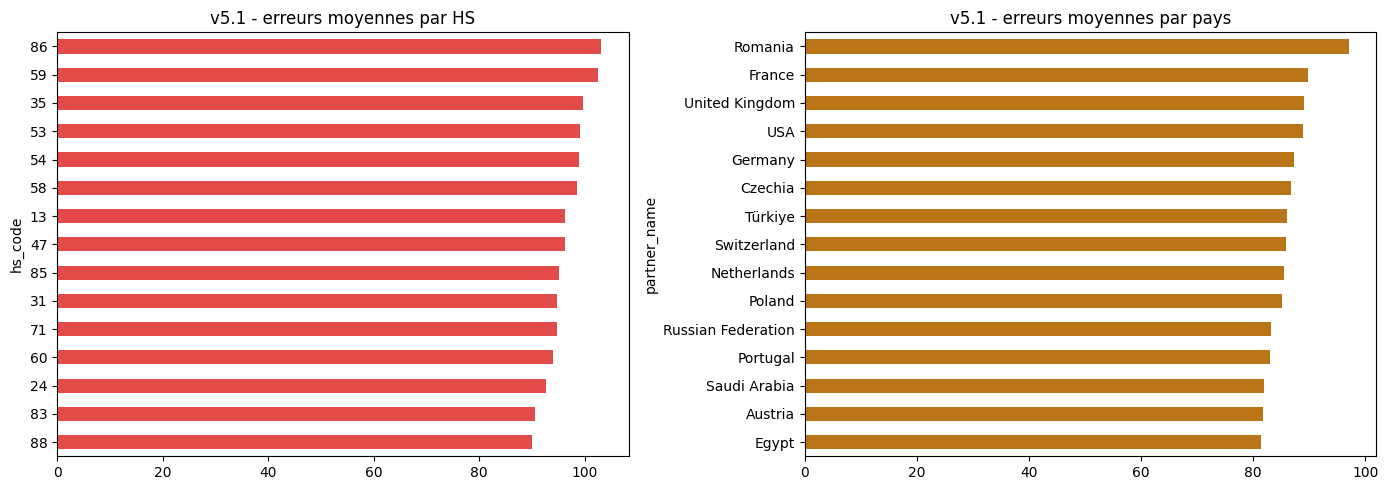

figure: C:\Users\HP\Desktop\MaroTrade Intelligence\notebooks\figures\v5_1_07_feature_importance.png


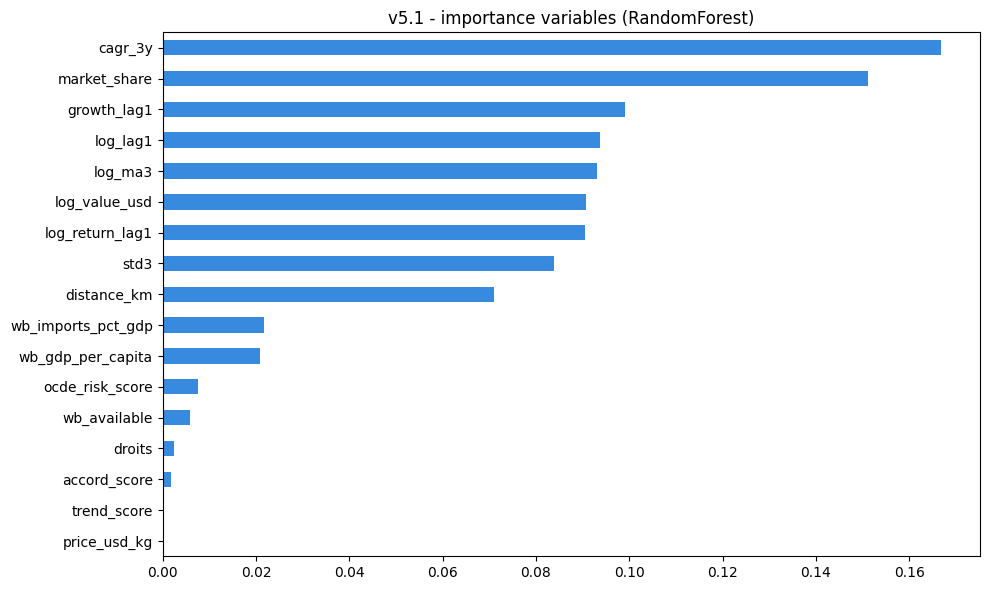

saved C:\Users\HP\Desktop\MaroTrade Intelligence\artifacts\benchmark_phase1_v5_1_results.json
saved C:\Users\HP\Desktop\MaroTrade Intelligence\artifacts\market_ranking_model_v5_1.joblib
figures ['v5_1_01_data_quality_before_training.png', 'v5_1_02_filter_funnel_before_training.png', 'v5_1_03_feature_diagnostics_before_training.png', 'v5_1_04_final_model_comparison.png', 'v5_1_05_feature_ablation.png', 'v5_1_06_error_analysis.png', 'v5_1_07_feature_importance.png']


In [7]:
pred=np.array(RESULTS[BEST_KEY]['pred_test'])
err=test[['hs_code','partner_code','partner_name','year','log_return']].copy()
err['y_pred']=pred
err['abs_error']=(err['log_return']-err['y_pred']).abs()
err_hs=err.groupby('hs_code')['abs_error'].agg(['mean','median','count']).sort_values('mean',ascending=False)
err_ct=err.groupby('partner_name')['abs_error'].agg(['mean','median','count']).sort_values('mean',ascending=False)
fig, axes=plt.subplots(1,2,figsize=(14,5))
err_hs.head(15)['mean'].sort_values().plot(kind='barh',ax=axes[0],color='#E24B4A')
axes[0].set_title('v5.1 - erreurs moyennes par HS')
err_ct.head(15)['mean'].sort_values().plot(kind='barh',ax=axes[1],color='#BA7517')
axes[1].set_title('v5.1 - erreurs moyennes par pays')
plt.tight_layout(); safe_savefig('v5_1_06_error_analysis.png'); plt.show()

best_model=FITTED[BEST_KEY]
features=PREP[BEST_FEATURE_SET]['features']
imp=None
if hasattr(best_model,'coef_'):
    imp=pd.Series(np.abs(best_model.coef_),index=features).sort_values(ascending=False)
elif hasattr(best_model,'feature_importances_'):
    imp=pd.Series(best_model.feature_importances_,index=features).sort_values(ascending=False)
if imp is not None:
    fig,ax=plt.subplots(figsize=(10,6))
    imp.head(20).sort_values().plot(kind='barh',ax=ax,color='#378ADD')
    ax.set_title(f'v5.1 - importance variables ({BEST_MODEL})')
    plt.tight_layout(); safe_savefig('v5_1_07_feature_importance.png'); plt.show()

artifact={'version':'benchmark_phase1_v5_1_final','best_key':BEST_KEY,'best_model':BEST_MODEL,'feature_set':BEST_FEATURE_SET,'best_feature_set':BEST_FEATURE_SET,'selection_reason':selection_reason,'features':features,'metrics':RESULTS[BEST_KEY],'split':{'train_year_max':int(train['year'].max()),'val_years':[int(x) for x in val_years],'test_feature_year':int(latest_feature_year),'test_target_year':int(latest_feature_year+1)},'raw_audit':audit_raw,'filter_funnel':funnel_df.to_dict('records'),'results':{k:{kk:vv for kk,vv in r.items() if kk!='pred_test'} for k,r in RESULTS.items()},'summary':summary.to_dict('records')}
with open(ARTIFACTS_DIR/'benchmark_phase1_v5_1_results.json','w',encoding='utf-8') as f: json.dump(artifact,f,ensure_ascii=False,indent=2)
if joblib is not None:
    joblib.dump({'model':best_model,'scaler':PREP[BEST_FEATURE_SET]['scaler'],'medians':PREP[BEST_FEATURE_SET]['medians'],'features':features,'metadata':artifact}, ARTIFACTS_DIR/'market_ranking_model_v5_1.joblib')
print('saved', ARTIFACTS_DIR/'benchmark_phase1_v5_1_results.json')
print('saved', ARTIFACTS_DIR/'market_ranking_model_v5_1.joblib')
print('figures', [p.name for p in sorted(FIGURES_DIR.glob('v5_1_*.png'))])